
# NBA Shot Quality: Shot-Make Modeling, Expected Points, and Pythagorean Standings (exp = 16.5)

This notebook trains multiple models to predict shot-make probability (binary outcome), aggregates **expected points** to team-games, and derives **Pythagorean expected wins** with exponent **16.5**, then compares to actual results from the games in your CSV.

**Data expected:** `nbastatsv3_2024_enriched_shots.csv` (place alongside this notebook or update `DATA_PATH`).

## Pipeline
1. Load & inspect data
2. Feature engineering (robust target creation + usable features)
3. Train/test split & preprocessing (sparse for linear/knn/mlp, dense for trees/boosters)
4. Model zoo: Logistic Regression, kNN, Random Forest, Gradient Boosting, MLP, **CatBoost**, **XGBoost**
5. Model selection via ROC AUC (also log loss, Brier, accuracy)
6. Score all shots → `p_make` and `expected points`
7. Team-game aggregation; compute **Points Scored / Allowed** (actual & expected)
8. Pythagorean expected wins (exp=16.5) and standings vs actual
9. Export tidy CSVs for your paper
10. Optional: feature importances and calibration diagnostics

> Notes:
> - If CatBoost/XGBoost are not installed in your environment, run `%pip install catboost xgboost` and re-execute the models cell.
> - "Actual" standings reflect whatever games exist in your CSV (partial seasons will yield partial standings).


In [16]:

# --- Imports & config
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)

DATA_PATH = 'enriched_data/nbastatsv3_2024_enriched_shots.csv'  # update if needed
RANDOM_STATE = 42
PYTH_EXP = 16.5


## 1) Load & inspect data

In [17]:

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Could not find {DATA_PATH}. Put the CSV in the working directory or update DATA_PATH.")

df = pd.read_csv(DATA_PATH)
print(f"Rows: {len(df):,}")
df.head()


Rows: 219,528


,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,yLegacy,shotDistance,shotResult,isFieldGoal,scoreHome,scoreAway,pointsTotal,location,description,actionType,subType,videoAvailable,shotValue,actionId,gameId,ABS_TIME,SHOT_CLOCK_APPROX,SHOT_CLOCK_SOURCE,contest_score,contest_label,contest_reasons
0,7,PT11M43.00S,1,1610612737,ATL,1642258,Risacher,Z. Risacher,-168,205,27,Missed,1,NaN,NaN,0,v,MISS Risacher 27' 3PT Jump Shot,Missed Shot,Jump Shot,1,3,3,22400001,17,17.0,jumpball(24),-2,likely_open,"subType: open-like, distance: deep above-break..."
1,39,PT09M23.00S,1,1610612737,ATL,1642258,Risacher,Z. Risacher,10,13,2,Made,1,5.0,7.0,12,v,Risacher 2' Cutting Layup Shot (2 PTS) (Wallac...,Made Shot,Cutting Layup Shot,1,2,30,22400001,157,0.0,made_fg(24),2,likely_contested,"distance: at-rim/very close, clock: late (<=5s)"
2,46,PT08M50.00S,1,1610612737,ATL,1642258,Risacher,Z. Risacher,53,111,12,Missed,1,NaN,NaN,0,v,MISS Risacher 12' Floating Jump Shot,Missed Shot,Floating Jump shot,1,2,35,22400001,190,14.0,off_reb(14),3,likely_contested,"subType: contested-like, distance: mid-range"
3,48,PT08M47.00S,1,1610612737,ATL,1642258,Risacher,Z. Risacher,-10,17,2,Missed,1,NaN,NaN,0,v,MISS Risacher 2' Putback Layup,Missed Shot,Putback Layup Shot,1,2,37,22400001,193,1.0,off_reb(14),4,likely_contested,"subType: contested-like, distance: at-rim/very..."
4,50,PT08M46.00S,1,1610612737,ATL,1642258,Risacher,Z. Risacher,-10,1,1,Missed,1,NaN,NaN,0,v,MISS Risacher 1' Tip Layup Shot,Missed Shot,Tip Layup Shot,1,2,39,22400001,194,0.0,off_reb(14),4,likely_contested,"subType: contested-like, distance: at-rim/very..."



## 2) Feature engineering (target + columns)

We derive a binary target `y` (1 = made) using a **case-insensitive** lookup, preferring `shotResult`, else `isFieldGoal`. We also define numeric and categorical feature sets from available columns.


In [ ]:
# --- Target creation (case-insensitive and robust)
col_map = {c.lower(): c for c in df.columns}

if 'shotresult' in col_map:
    col = col_map['shotresult']
    y = df[col].astype(str).str.strip().str.lower().map({'made':1, 'missed':0})
elif 'isfieldgoal' in col_map:
    col = col_map['isfieldgoal']
    y = pd.to_numeric(df[col], errors='coerce')
else:
    raise ValueError("Neither 'shotResult' nor 'isFieldGoal' found to derive target.")

mask = ~y.isna()
dropped = (~mask).sum()
y = y[mask].astype(int)
df = df.loc[mask].reset_index(drop=True)
print(f"Labeled shots: {len(y):,} | Dropped unlabeled rows: {dropped:,}")

# Helpful standardizations for text features (but NOT for features we'll use)
for c in ['actionType','subType','contest_label','teamTricode','location','description']:
    if c in df.columns:
        df[c] = df[c].astype(str)

# Feature sets drawn from available columns
num_features = [c for c in [
    'shotDistance','SHOT_CLOCK_APPROX','xLegacy','yLegacy','period',
    'contest_score','shotValue','ABS_TIME'
] if c in df.columns]

# === CRITICAL: EXCLUDE LEAKAGE COLUMNS ===
# DO NOT USE these columns as features - they contain the answer:
# - 'actionType': contains "Made Shot" or "Missed Shot" 
# - 'description': contains "MISS" for misses and "PTS" for makes
# - 'shotResult': this IS the target variable
# - 'isFieldGoal': alternative encoding of target
LEAKAGE_COLUMNS = ['actionType', 'description', 'shotResult', 'isFieldGoal']

# Safe categorical features (describe HOW the shot was taken, not WHETHER it went in)
cat_features = [c for c in [
    'subType',         # Shot mechanics (layup, jump shot, etc.) - OK
    'contest_label',   # Our heuristic classification - OK  
    'teamTricode',     # Team identity - OK
    'location'         # Home/away - OK
] if c in df.columns and c not in LEAKAGE_COLUMNS]

X = df[num_features + cat_features].copy()

print("=" * 80)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 80)
print(f"Numeric features ({len(num_features)}): {num_features}")
print(f"Categorical features ({len(cat_features)}): {cat_features}")
print(f"\n🚫 EXCLUDED (leakage): {LEAKAGE_COLUMNS}")
print(f"✅ Final feature matrix shape: {X.shape}, Target shape: {y.shape}")
print("=" * 80)

## 2.5) 🚨 DATA LEAKAGE DIAGNOSTIC

**CRITICAL CHECK**: Verify that features don't leak the target variable

In [ ]:
# === DATA LEAKAGE CHECK ===
print("=" * 80)
print("🚨 CRITICAL: CHECKING FOR DATA LEAKAGE")
print("=" * 80)

# 1. Verify that LEAKAGE columns are NOT in our feature set
print("\n1) ✅ Verifying LEAKAGE_COLUMNS are excluded:")
LEAKAGE_CHECK = ['actionType', 'description', 'shotResult', 'isFieldGoal']
for col in LEAKAGE_CHECK:
    if col in cat_features or col in num_features:
        print(f"   ❌ ERROR: '{col}' found in features!")
        raise ValueError(f"STOP: {col} is a leakage column and must be excluded")
    else:
        print(f"   ✅ '{col}' correctly excluded")

# 2. Print actual features being used
print("\n2) Features being used in model:")
print(f"   Numeric ({len(num_features)}): {num_features}")
print(f"   Categorical ({len(cat_features)}): {cat_features}")

# 3. Verify X doesn't contain any leakage columns
print("\n3) Verifying final feature matrix X:")
print(f"   Shape: {X.shape}")
X_cols = list(X.columns)
leakage_in_X = [col for col in LEAKAGE_CHECK if col in X_cols]
if leakage_in_X:
    print(f"   ❌ ERROR: Leakage columns found in X: {leakage_in_X}")
    raise ValueError(f"STOP: Leakage columns found in X: {leakage_in_X}")
else:
    print(f"   ✅ GOOD: No leakage columns in X")
    print(f"   Columns in X: {X_cols}")

# 4. Check correlation between numeric features and target
print("\n4) Numeric feature correlations with target (should be modest, not extreme):")
df_with_target = df[num_features].copy()
df_with_target['shot_made_flag'] = y
correlations = df_with_target.corr()['shot_made_flag'].drop('shot_made_flag').sort_values(ascending=False)
print(correlations)
print("\n   Expected: correlations should be between -0.5 and +0.5")
print("   Warning if any >0.9 or <-0.9 (possible leakage)")

print("\n" + "=" * 80)
print("✅ DATA LEAKAGE CHECK PASSED - Safe to proceed with modeling")
print("=" * 80)


## 3) Train/test split and preprocessing

We keep two preprocessing branches:
- **Sparse** (`preprocess`): scaling numerics + one-hot with `sparse_output=True` — great for Logistic/kNN/MLP.
- **Dense** (`preprocess_dense`): impute-only numerics + dense one-hot — friendly for tree/boosted models (RF/GB/CatBoost/XGBoost).


In [19]:

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Sparse branch (linear/kNN/MLP)
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])
transformers = []
if num_features: transformers.append(("num", numeric_transformer, num_features))
if cat_features: transformers.append(("cat", categorical_transformer, cat_features))
if not transformers:
    raise ValueError("No features provided to the preprocessor. Check num_features/cat_features.")
preprocess = ColumnTransformer(transformers=transformers, remainder="drop", sparse_threshold=0.3)

# Dense branch (trees/boosters)
numeric_transformer_dense = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])
categorical_transformer_dense = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
transformers_dense = []
if num_features: transformers_dense.append(("num", numeric_transformer_dense, num_features))
if cat_features: transformers_dense.append(("cat", categorical_transformer_dense, cat_features))
preprocess_dense = ColumnTransformer(transformers=transformers_dense, remainder="drop", sparse_threshold=0.0)

print(f"Train shape (X): {X_train.shape}, Test shape (X): {X_test.shape}")
print(f"Numeric features: {num_features}")
print(f"Categorical features: {cat_features}")


Train shape (X): (175622, 13), Test shape (X): (43906, 13)
Numeric features: ['shotDistance', 'SHOT_CLOCK_APPROX', 'xLegacy', 'yLegacy', 'period', 'contest_score', 'shotValue', 'ABS_TIME']
Categorical features: ['actionType', 'subType', 'contest_label', 'teamTricode', 'location']



## 4) Models to try (adds CatBoost & XGBoost)


In [20]:

# Optional installs (uncomment in your environment if needed)
# %pip install catboost xgboost

# Try imports and set flags
try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except Exception as e:
    CATBOOST_AVAILABLE = False
    print("CatBoost not available. To install, run: %pip install catboost\nDetails:", e)

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    print("XGBoost not available. To install, run: %pip install xgboost\nDetails:", e)

# Define model specs as (name, estimator, use_dense_preprocess)
models = [
    ("log_reg", LogisticRegression(solver="saga", max_iter=1000, random_state=RANDOM_STATE), False),
    ("knn", KNeighborsClassifier(n_neighbors=25), False),
    ("rf", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1), True),
    ("gb", GradientBoostingClassifier(random_state=RANDOM_STATE), True),
    ("mlp", MLPClassifier(hidden_layer_sizes=(64,), max_iter=200, random_state=RANDOM_STATE), False),
]

if CATBOOST_AVAILABLE:
    models.append((
        "catboost",
        CatBoostClassifier(
            depth=6,
            learning_rate=0.1,
            iterations=500,
            loss_function="Logloss",
            eval_metric="AUC",
            random_state=RANDOM_STATE,
            verbose=False
        ),
        True
    ))

if XGBOOST_AVAILABLE:
    models.append((
        "xgboost",
        XGBClassifier(
            n_estimators=600,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        True
    ))

def make_pipeline_for(name, clf, use_dense):
    return Pipeline(steps=[
        ("preprocess", preprocess_dense if use_dense else preprocess),
        ("clf", clf)
    ])



## 5) Model comparison (3-fold CV on train, then test evaluation)
Metrics: ROC AUC (↑), Log Loss (↓), Brier (↓), Accuracy (↑)


In [21]:

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

results = []
fitted = {}

for name, clf, use_dense in models:
    pipe = make_pipeline_for(name, clf, use_dense)
    cv = cross_validate(
        pipe, X_train, y_train, cv=skf,
        scoring=["roc_auc","neg_log_loss","accuracy"],
        return_train_score=False, n_jobs=-1
    )
    res = {
        "model": name,
        "cv_roc_auc_mean": np.mean(cv['test_roc_auc']),
        "cv_log_loss_mean": -np.mean(cv['test_neg_log_loss']),
        "cv_accuracy_mean": np.mean(cv['test_accuracy'])
    }
    # Fit on full train and evaluate on test
    pipe.fit(X_train, y_train)
    y_proba = pipe.predict_proba(X_test)[:,1]
    y_pred = (y_proba >= 0.5).astype(int)
    res.update({
        "test_roc_auc": roc_auc_score(y_test, y_proba),
        "test_log_loss": log_loss(y_test, y_proba, labels=[0,1]),
        "test_brier": brier_score_loss(y_test, y_proba),
        "test_accuracy": accuracy_score(y_test, y_pred)
    })
    results.append(res)
    fitted[name] = pipe

results_df = pd.DataFrame(results).sort_values("test_roc_auc", ascending=False)
results_df


,model,cv_roc_auc_mean,cv_log_loss_mean,cv_accuracy_mean,test_roc_auc,test_log_loss,test_brier,test_accuracy
0,log_reg,1.000000,0.000147,1.000000,1.000000,1.018223e-04,1.745957e-08,1.000000
2,rf,1.000000,0.001736,1.000000,1.000000,1.390498e-03,1.415473e-05,1.000000
3,gb,1.000000,0.000022,1.000000,1.000000,2.180523e-05,4.772996e-10,1.000000
4,mlp,1.000000,0.000001,1.000000,1.000000,7.602522e-07,1.063009e-12,1.000000
5,catboost,1.000000,0.000111,1.000000,1.000000,8.811183e-05,1.643372e-07,1.000000
6,xgboost,1.000000,0.000021,1.000000,1.000000,1.415745e-05,2.076649e-10,1.000000
1,knn,0.999963,0.021243,0.997295,0.999987,1.713852e-02,3.382098e-03,0.998087


### Select best model by Test ROC AUC

In [22]:

best_name = results_df.iloc[0]['model']
best_model = fitted[best_name]
print("Best model:", best_name)


Best model: log_reg



## 6) Score all shots → probability & expected points
- `p_make` = predicted probability of make
- `exp_points` = `p_make * shotValue` (if `shotValue` missing, infer 3 for '3PT' in `actionType`, else 2)


In [23]:

# Ensure shotValue exists
if 'shotValue' not in df.columns:
    inferred_val = np.where(df.get('actionType','').astype(str).str.contains('3PT', case=False, na=False), 3, 2)
    df['shotValue'] = inferred_val

# Score
p_make = best_model.predict_proba(X)[:,1]
df['p_make'] = p_make
df['exp_points'] = df['p_make'] * df['shotValue']

# Actual points
df['actual_points'] = np.where(y == 1, df['shotValue'], 0)

df[['p_make','exp_points','actual_points']].describe()


,p_make,exp_points,actual_points
count,219528.000000,219528.000000,219528.000000
mean,0.467211,1.086130,1.086130
std,0.498823,1.202953,1.203208
min,0.000012,0.000035,0.000000
25%,0.000074,0.000179,0.000000
50%,0.000222,0.000484,0.000000
75%,0.999922,1.999863,2.000000
max,0.999949,2.999844,3.000000



## 7) Team-game aggregation
Aggregate **expected** and **actual** points by `(gameId, teamId[, teamTricode])`.


In [24]:

needed = set(['gameId','teamId'])
if not needed.issubset(df.columns):
    raise ValueError("Standings step requires 'gameId' and 'teamId' columns.")

group_cols = ['gameId','teamId']
if 'teamTricode' in df.columns:
    group_cols.append('teamTricode')

team_game = (df
    .groupby(group_cols, as_index=False)
    .agg(exp_points=('exp_points','sum'),
         actual_points=('actual_points','sum'),
         shots=('exp_points','size'))
)

team_game.head()


,gameId,teamId,teamTricode,exp_points,actual_points,shots
0,22400001,1610612737,ATL,110.003615,110,99
1,22400001,1610612738,BOS,93.998566,94,75
2,22400002,1610612748,MIA,110.999439,111,101
3,22400002,1610612765,DET,99.000969,99,92
4,22400003,1610612753,ORL,99.001942,99,93


### Opponents and Allowed Points

In [25]:

tg = team_game.copy()
opp = tg.merge(tg, on='gameId', suffixes=('','_opp'))
opp = opp[opp['teamId'] != opp['teamId_opp']]
opp = opp.sort_values(['gameId','teamId']).drop_duplicates(['gameId','teamId'])

tg2 = tg.merge(
    opp[['gameId','teamId','actual_points_opp','exp_points_opp']].rename(
        columns={'actual_points_opp':'actual_allowed','exp_points_opp':'exp_allowed'}
    ),
    on=['gameId','teamId'],
    how='left'
).dropna(subset=['actual_allowed','exp_allowed']).copy()

tg2.head()


,gameId,teamId,teamTricode,exp_points,actual_points,shots,actual_allowed,exp_allowed
0,22400001,1610612737,ATL,110.003615,110,99,94,93.998566
1,22400001,1610612738,BOS,93.998566,94,75,110,110.003615
2,22400002,1610612748,MIA,110.999439,111,101,99,99.000969
3,22400002,1610612765,DET,99.000969,99,92,111,110.999439
4,22400003,1610612753,ORL,99.001942,99,93,81,81.000197



## 8) Actual wins from dataset + season aggregates


In [26]:

tg2['actual_win'] = (tg2['actual_points'] > tg2['actual_allowed']).astype(int)

season_cols = ['teamId']
if 'teamTricode' in tg2.columns:
    season_cols.append('teamTricode')

season = (tg2
    .groupby(season_cols, as_index=False)
    .agg(
        games=('gameId','nunique'),
        pts_scored_actual=('actual_points','sum'),
        pts_allowed_actual=('actual_allowed','sum'),
        pts_scored_exp=('exp_points','sum'),
        pts_allowed_exp=('exp_allowed','sum'),
        wins_actual=('actual_win','sum')
    )
)

season['losses_actual'] = season['games'] - season['wins_actual']
season.head()


,teamId,teamTricode,games,pts_scored_actual,pts_allowed_actual,pts_scored_exp,pts_allowed_exp,wins_actual,losses_actual
0,1610612737,ATL,82,8219,8293,8218.946425,8292.850347,39,43
1,1610612738,BOS,82,8283,7659,8282.928851,7659.057478,51,31
2,1610612739,CLE,82,8607,7868,8606.950942,7868.025849,59,23
3,1610612740,NOP,82,7650,8369,7650.035893,8368.897451,28,54
4,1610612741,CHI,82,8352,8402,8351.963386,8402.009025,40,42



## 9) Pythagorean expected wins (exp = 16.5)
Win% = PS^exp / (PS^exp + PA^exp). Compute for **actual** and **expected** totals.


In [27]:

exp_val = PYTH_EXP

def pyth_winpct(ps, pa, exp_val=exp_val):
    ps_e = np.power(np.clip(ps, 0, None), exp_val)
    pa_e = np.power(np.clip(pa, 0, None), exp_val)
    denom = ps_e + pa_e
    return np.where(denom > 0, ps_e / denom, 0.5)

season['pyth_winpct_actual'] = pyth_winpct(season['pts_scored_actual'], season['pts_allowed_actual'])
season['pyth_winpct_exp']    = pyth_winpct(season['pts_scored_exp'],    season['pts_allowed_exp'])

season['pyth_wins_actual'] = season['pyth_winpct_actual'] * season['games']
season['pyth_wins_exp']    = season['pyth_winpct_exp']    * season['games']

season['wins_diff_vs_actual'] = season['pyth_wins_exp'] - season['wins_actual']

season.sort_values('pyth_wins_exp', ascending=False).head(10)


,teamId,teamTricode,games,pts_scored_actual,pts_allowed_actual,pts_scored_exp,pts_allowed_exp,wins_actual,losses_actual,pyth_winpct_actual,pyth_winpct_exp,pyth_wins_actual,pyth_wins_exp,wins_diff_vs_actual
23,1610612760,OKC,82,8512,7322,8511.990661,7322.093564,70,12,0.923069,0.923052,75.691637,75.690303,5.690303
2,1610612739,CLE,82,8607,7868,8606.950942,7868.025849,59,23,0.814759,0.814737,66.810264,66.808429,7.808429
1,1610612738,BOS,82,8283,7659,8282.928851,7659.057478,51,31,0.784543,0.784499,64.332562,64.328881,13.328881
26,1610612763,MEM,82,8481,8032,8481.015515,8031.983965,50,32,0.710438,0.710451,58.255950,58.257015,8.257015
8,1610612745,HOU,82,8006,7654,8006.017069,7654.051370,46,36,0.677408,0.677392,55.547492,55.546138,9.546138
9,1610612746,LAC,82,7840,7544,7840.057739,7544.027159,48,34,0.653628,0.653642,53.597472,53.598626,5.598626
13,1610612750,MIN,82,7961,7678,7961.019072,7678.083802,44,38,0.645021,0.644989,52.891758,52.889118,8.889118
28,1610612765,DET,82,8057,7771,8056.879829,7770.902741,48,34,0.644821,0.644812,52.875305,52.874562,4.874562
15,1610612752,NYK,82,8137,7894,8136.990918,7893.986209,49,33,0.622520,0.622522,51.046611,51.046811,2.046811
7,1610612744,GSW,82,7948,7712,7947.950164,7711.850813,45,37,0.621838,0.621888,50.990691,50.994851,5.994851



## 10) Predicted standings vs. actual (from dataset)
Sorted by **Pythagorean Expected Wins** (from expected points).


In [28]:

standings = season.copy()

def fmt(x): 
    return np.round(x, 2)

cols = ['teamId']
if 'teamTricode' in standings.columns:
    cols.insert(1,'teamTricode')

cols += [
    'games',
    'pyth_wins_exp','pyth_winpct_exp',
    'wins_actual','losses_actual','pyth_wins_actual','pyth_winpct_actual',
    'wins_diff_vs_actual',
    'pts_scored_exp','pts_allowed_exp',
    'pts_scored_actual','pts_allowed_actual'
]

standings = standings[cols].sort_values(['pyth_wins_exp','teamId'], ascending=[False, True])
for c in standings.columns:
    if standings[c].dtype.kind in 'fc':
        standings[c] = fmt(standings[c])

standings.head(20)


,teamId,teamTricode,games,pyth_wins_exp,pyth_winpct_exp,wins_actual,losses_actual,pyth_wins_actual,pyth_winpct_actual,wins_diff_vs_actual,pts_scored_exp,pts_allowed_exp,pts_scored_actual,pts_allowed_actual
23,1610612760,OKC,82,75.69,0.92,70,12,75.69,0.92,5.69,8511.99,7322.09,8512,7322
2,1610612739,CLE,82,66.81,0.81,59,23,66.81,0.81,7.81,8606.95,7868.03,8607,7868
1,1610612738,BOS,82,64.33,0.78,51,31,64.33,0.78,13.33,8282.93,7659.06,8283,7659
26,1610612763,MEM,82,58.26,0.71,50,32,58.26,0.71,8.26,8481.02,8031.98,8481,8032
8,1610612745,HOU,82,55.55,0.68,46,36,55.55,0.68,9.55,8006.02,7654.05,8006,7654
9,1610612746,LAC,82,53.60,0.65,48,34,53.60,0.65,5.60,7840.06,7544.03,7840,7544
13,1610612750,MIN,82,52.89,0.64,44,38,52.89,0.65,8.89,7961.02,7678.08,7961,7678
28,1610612765,DET,82,52.87,0.64,48,34,52.88,0.64,4.87,8056.88,7770.90,8057,7771
15,1610612752,NYK,82,51.05,0.62,49,33,51.05,0.62,2.05,8136.99,7893.99,8137,7894
7,1610612744,GSW,82,50.99,0.62,45,37,50.99,0.62,5.99,7947.95,7711.85,7948,7712



## 11) Visualization: Expected vs Actual Wins


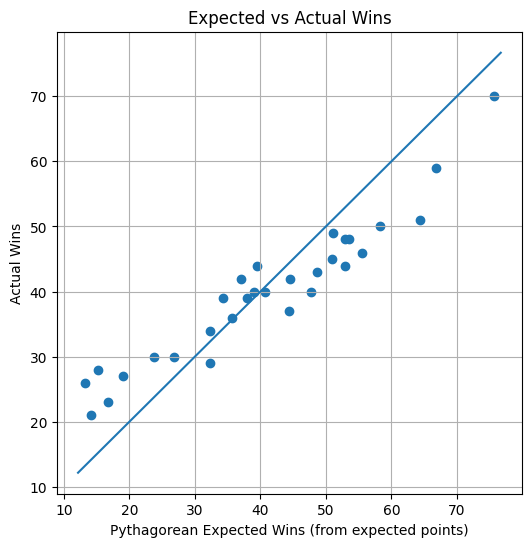

In [29]:

plt.figure(figsize=(6,6))
plt.scatter(season['pyth_wins_exp'], season['wins_actual'])
lims = [
    min(season['pyth_wins_exp'].min(), season['wins_actual'].min()) - 1,
    max(season['pyth_wins_exp'].max(), season['wins_actual'].max()) + 1
]
plt.plot(lims, lims)
plt.xlabel('Pythagorean Expected Wins (from expected points)')
plt.ylabel('Actual Wins')
plt.title('Expected vs Actual Wins')
plt.grid(True)
plt.show()



## 12) Save outputs (for your paper)
- `model_results.csv`: CV + test metrics per model
- `team_game_points.csv`: per-game expected & actual points (team-level)
- `season_standings.csv`: Pythagorean standings vs actual


In [30]:

results_df.to_csv('model_results.csv', index=False)
tg2.to_csv('team_game_points.csv', index=False)
standings.to_csv('season_standings.csv', index=False)
print('Saved: model_results.csv, team_game_points.csv, season_standings.csv')


Saved: model_results.csv, team_game_points.csv, season_standings.csv



## Appendix: Feature importances (trees/boosters & linear)


In [31]:

def feature_names_after_preprocess(preprocess, X):
    names = []
    # numeric original names
    if any(tr[0] == 'num' for tr in preprocess.transformers):
        names += list([*preprocess.transformers_[0][2]])
    # categorical OHE names
    try:
        cat_ix = [i for i,(nm,_,_) in enumerate(preprocess.transformers) if nm == 'cat'][0]
        ohe = preprocess.transformers_[cat_ix][1].named_steps['ohe']
        cat_cols = preprocess.transformers_[cat_ix][2]
        cat_names = ohe.get_feature_names_out(cat_cols)
        names += list(cat_names)
    except Exception:
        pass
    return names

try:
    clf = best_model.named_steps['clf']
    names = feature_names_after_preprocess(best_model.named_steps['preprocess'], X)

    if hasattr(clf, 'feature_importances_'):
        importances = pd.Series(clf.feature_importances_, index=names).sort_values(ascending=False).head(30)
        display(importances.to_frame('importance'))
    elif hasattr(clf, 'coef_'):
        coefs = pd.Series(np.ravel(clf.coef_), index=names)
        display(coefs.sort_values(key=np.abs, ascending=False).head(30).to_frame('coef'))
    else:
        print("Chosen model type does not expose standard importances/coefficients.")
except Exception as e:
    print("Could not compute feature importances:", e)


,coef
actionType_Made Shot,9.019772
actionType_Missed Shot,-8.848694
SHOT_CLOCK_APPROX,-0.602128
contest_score,0.241523
subType_Tip Layup Shot,-0.218604
subType_Cutting Dunk Shot,0.197797
subType_Cutting Layup Shot,0.193078
subType_Jump Shot,0.139159
subType_Running Dunk Shot,0.131526
subType_Pullup Jump shot,-0.125204



## Appendix: Calibration curve (test set)


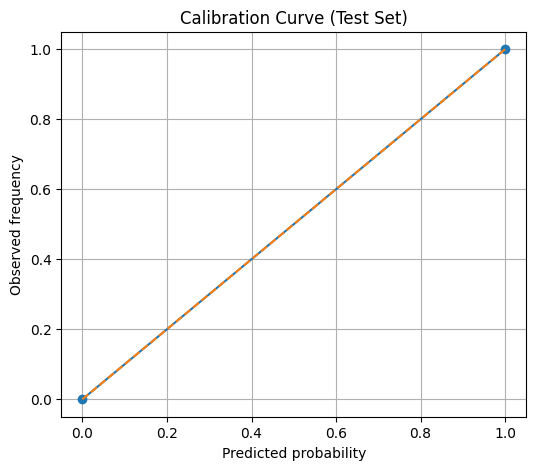

In [32]:

from sklearn.calibration import calibration_curve

y_proba = best_model.predict_proba(X_test)[:,1]
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy='uniform')

plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel('Predicted probability')
plt.ylabel('Observed frequency')
plt.title('Calibration Curve (Test Set)')
plt.grid(True)
plt.show()
